In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from fnmatch import fnmatch

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error
from keras import models, layers, optimizers
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import os

2025-11-02 18:57:01.254867: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
from pathlib import Path
from fnmatch import fnmatch
import pandas as pd

root = (Path.cwd() / "apt_prices_poland")
if not root.exists():
    root = Path.cwd().parent / "apt_prices_poland"  

skip_pattern = "apartments_rent_pl_*.csv"

csv_paths = [
    path
    for path in root.rglob("*.csv")
    if not fnmatch(path.name, skip_pattern)
]

if not csv_paths:
    raise FileNotFoundError(f"No CSV files found under {root}")

frames = [pd.read_csv(p) for p in csv_paths]
combined = pd.concat(frames, ignore_index=True)


In [4]:
df = combined.copy()

In [5]:
df["price_per_sqm"] = df["price"] / np.clip(df["squareMeters"], 1e-6, None)

# sanity/outlier filters (tweak if needed)
# df = df[(df["squareMeters"] >= 10) & (df["squareMeters"] <= 4000)]
# df = df[(df["price_per_sqm"] > 500) & (df["price_per_sqm"] < 100_000)]


In [6]:
num_feats = [
    "squareMeters","rooms","floor","floorCount","buildYear",
    "latitude","longitude","centreDistance","poiCount",
    "schoolDistance","clinicDistance","postOfficeDistance",
    "kindergartenDistance","restaurantDistance","collegeDistance","pharmacyDistance"
]
cat_low = ["type","ownership"]  # low-cardinality categoricals
id_col = "id"
target_col = "price_per_sqm"

In [7]:

available = [c for c in num_feats + cat_low + [id_col, target_col] if c in df.columns]
df = df[available].copy()


In [8]:
for c in cat_low:
    if c in df.columns:
        df[c] = df[c].astype("string").fillna("Unknown")

In [9]:
groups = df[id_col].values

gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
train_idx, test_idx = next(gss1.split(df, groups=groups))
df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)


In [10]:
# From the remaining training set, carve out a validation set (again group-wise)
groups_tr = df_train[id_col].values
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)  # ~0.15/0.85 → final split 70/15/15
tr_idx, val_idx = next(gss2.split(df_train, groups=groups_tr))
df_tr  = df_train.iloc[tr_idx].reset_index(drop=True)
df_val = df_train.iloc[val_idx].reset_index(drop=True)

X_tr  = df_tr[num_feats + cat_low]
y_tr  = df_tr[target_col].values
X_val = df_val[num_feats + cat_low]
y_val = df_val[target_col].values
X_te  = df_test[num_feats + cat_low]
y_te  = df_test[target_col].values

In [11]:
#Preprocessing (impute + scale numerics; impute + one-hot categoricals)
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

pre = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, [c for c in num_feats if c in X_tr.columns]),
        ("cat", categorical_pipeline, [c for c in cat_low if c in X_tr.columns]),
    ],
    remainder="drop"
)

In [12]:
# Fit on train, transform all
X_tr_p  = pre.fit_transform(X_tr)
X_val_p = pre.transform(X_val)
X_te_p  = pre.transform(X_te)

print("Train shape:", X_tr_p.shape, "Val shape:", X_val_p.shape, "Test shape:", X_te_p.shape)


Train shape: (136605, 23) Val shape: (29775, 23) Test shape: (29188, 23)


In [13]:
# Build Multi-Layer Perception model
def build_mlp(input_dim: int) -> models.Sequential:
    model = models.Sequential([
        layers.Dense(256, activation="relu", input_shape=(input_dim,)),
        layers.Dropout(0.25),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # regression
    ])
    model.compile(optimizer=optimizers.Adam(learning_rate=1e-3), loss="mse", metrics=["mae"])
    return model

model = build_mlp(X_tr_p.shape[1])

callbacks = [
    EarlyStopping(monitor="val_mae", patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_mae", factor=0.5, patience=5, min_lr=1e-5)
]

history = model.fit(
    X_tr_p, y_tr,
    validation_data=(X_val_p, y_val),
    epochs=100,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)


/Users/heesung/Documents/Poland/AGH/2025_Winter/Diploma/Raw/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 159064784.0000 - mae: 11288.3262 - val_loss: 28341046.0000 - val_mae: 4176.0156 - learning_rate: 0.0010
Epoch 2/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 21597612.0000 - mae: 3636.2874 - val_loss: 18040690.0000 - val_mae: 3317.7708 - learning_rate: 0.0010
Epoch 3/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 18279218.0000 - mae: 3346.0369 - val_loss: 16636452.0000 - val_mae: 3188.9666 - learning_rate: 0.0010
Epoch 4/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 17167684.0000 - mae: 3236.1904 - val_loss: 15825041.0000 - val_mae: 3103.2402 - learning_rate: 0.0010
Epoch 5/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 16450189.0000 - mae: 3160.5991 - val_loss: 15203977.0000 - val_mae: 3030.2058 - learning_rate: 0.0010
Epoch 6/100
134/134 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 15834182.0000 - mae: 3089.2090 - val_loss: 14627369.0000 - val_mae: 2960.0034 - learning_rate: 0.0010
Epoch 7/100
134/134

In [17]:
# Evaluate
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    # filter any NaNs/Infs just in case
    m = np.isfinite(y_true) & np.isfinite(y_pred)
    y_true = y_true[m]; y_pred = y_pred[m]

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  
    mape = np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1e-6, None))) * 100.0
    smape = 100.0 * np.mean(2.0 * np.abs(y_pred - y_true) /
                            (np.abs(y_pred) + np.abs(y_true) + 1e-9))

    return mae, rmse, mape, smape

In [20]:
y_val_pred = model.predict(X_val_p, verbose=0).ravel()
y_te_pred  = model.predict(X_te_p,  verbose=0).ravel()

val_mae, val_rmse, val_mape, val_smape = metrics(y_val, y_val_pred)
te_mae,  te_rmse,  te_mape,  te_smape  = metrics(y_te, y_te_pred)

val_r2 = r2_score(y_val, y_val_pred)
te_r2  = r2_score(y_te,  y_te_pred)

print(f"VALID — MAE: {val_mae:,.0f} PLN/m² | RMSE: {val_rmse:,.0f} | MAPE: {val_mape:.2f}% | sMAPE: {val_smape:.2f}% | R2:{val_r2:.4f}")
print(f"TEST  — MAE: {te_mae:,.0f} PLN/m² | RMSE: {te_rmse:,.0f} | MAPE: {te_mape:.2f}% | sMAPE: {te_smape:.2f}%|R2:{te_r2:.4f}")


VALID — MAE: 1,736 PLN/m² | RMSE: 2,391 | MAPE: 13.21% | sMAPE: 12.82% | R2:0.7727
TEST  — MAE: 1,754 PLN/m² | RMSE: 2,412 | MAPE: 13.35% | sMAPE: 12.94%|R2:0.7727


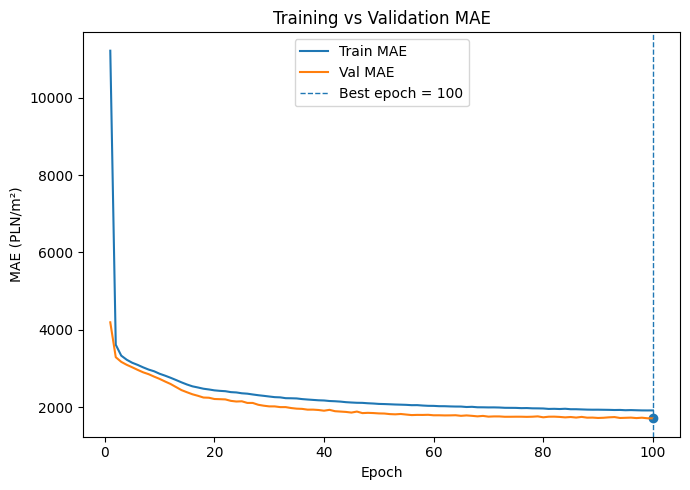

Best epoch: 100 | Best Val MAE: 1,716.92 PLN/m²


In [16]:
import numpy as np
import matplotlib.pyplot as plt

# -- Pull keys safely regardless of metric naming
hist = history.history
mae_key = "mae" if "mae" in hist else ("mean_absolute_error" if "mean_absolute_error" in hist else None)
val_mae_key = "val_mae" if "val_mae" in hist else ("val_mean_absolute_error" if "val_mean_absolute_error" in hist else None)

if mae_key is None or val_mae_key is None:
    raise ValueError(f"Could not find MAE keys in history. Available keys: {list(hist.keys())}")

train_mae = hist[mae_key]
val_mae = hist[val_mae_key]
epochs = np.arange(1, len(train_mae) + 1)

# -- Best epoch by validation MAE
best_epoch = int(np.argmin(val_mae) + 1)
best_val_mae = val_mae[best_epoch - 1]

plt.figure(figsize=(7, 5))
plt.plot(epochs, train_mae, label="Train MAE")
plt.plot(epochs, val_mae, label="Val MAE")
plt.axvline(best_epoch, linestyle="--", linewidth=1, label=f"Best epoch = {best_epoch}")
plt.scatter([best_epoch], [best_val_mae])

plt.title("Training vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE (PLN/m²)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best epoch: {best_epoch} | Best Val MAE: {best_val_mae:,.2f} PLN/m²")

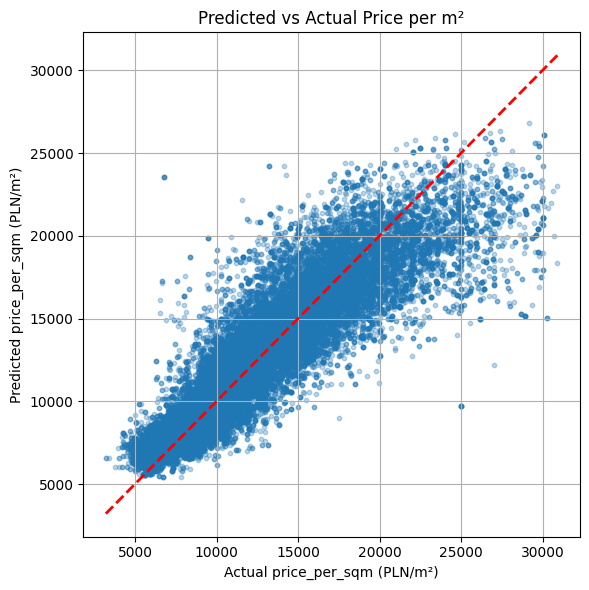

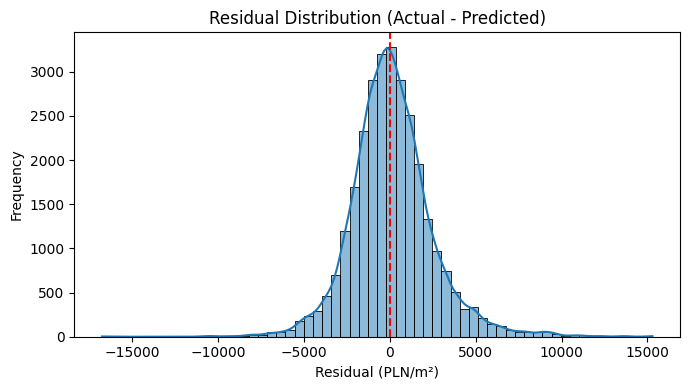

Mean residual: 130.99 PLN/m


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ---- Predicted vs Actual scatter ----
plt.figure(figsize=(6,6))
plt.scatter(y_te, y_te_pred, alpha=0.3, s=10)
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--', lw=2)
plt.xlabel("Actual price_per_sqm (PLN/m²)")
plt.ylabel("Predicted price_per_sqm (PLN/m²)")
plt.title("Predicted vs Actual Price per m²")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Residual distribution ----
residuals = y_te - y_te_pred

plt.figure(figsize=(7,4))
sns.histplot(residuals, bins=60, kde=True)
plt.axvline(0, color="red", linestyle="--")
plt.title("Residual Distribution (Actual - Predicted)")
plt.xlabel("Residual (PLN/m²)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Print residual summary
print(f"Mean residual: {np.mean(residuals):.2f} PLN/m")


### Now, lets predict price_per_sqm for each id 

In [18]:
num_feats = [
    "squareMeters","rooms","floor","floorCount","buildYear",
    "latitude","longitude","centreDistance","poiCount",
    "schoolDistance","clinicDistance","postOfficeDistance",
    "kindergartenDistance","restaurantDistance","collegeDistance","pharmacyDistance"
]
cat_low = ["type","ownership"]
feat_cols = [c for c in num_feats + cat_low if c in df.columns]

In [19]:
# Prepare input data
X_all = df[feat_cols].copy()
for c in (set(cat_low) & set(X_all.columns)):
    X_all[c] = X_all[c].astype("string").fillna("Unknown")

In [20]:
# Transform and predict price_per_sqm
X_all_p = pre.transform(X_all)
pred_ppsqm = model.predict(X_all_p, verbose=0).ravel()

In [21]:
# Attach predictions to the original rows
df_pred_rows = df.copy()
df_pred_rows["pred_price_per_sqm"] = pred_ppsqm
# If you want predicted TOTAL price too:
if "squareMeters" in df_pred_rows.columns:
    df_pred_rows["pred_price"] = df_pred_rows["pred_price_per_sqm"] * df_pred_rows["squareMeters"]


In [22]:
df_pred_rows

,squareMeters,rooms,floor,floorCount,buildYear,latitude,longitude,centreDistance,poiCount,schoolDistance,...,kindergartenDistance,restaurantDistance,collegeDistance,pharmacyDistance,type,ownership,id,price_per_sqm,pred_price_per_sqm,pred_price
0,105.00,4.0,3.0,4.0,2016.0,53.431503,14.485820,5.06,1.0,1.080,...,0.791,1.054,3.062,0.335,apartmentBuilding,condominium,a01d82c9529f98a54d64b9e061c9a73b,11428.561905,9592.128906,1.007174e+06
1,94.40,4.0,4.0,5.0,NaN,53.441253,14.511030,3.86,7.0,0.439,...,0.532,0.624,1.312,0.051,blockOfFlats,condominium,d68ea84e5d35da9e282150332bdc22f3,12182.203390,7585.140137,7.160372e+05
2,48.29,2.0,8.0,11.0,2014.0,53.399444,14.526111,3.53,8.0,0.109,...,0.178,0.166,2.296,0.141,Unknown,condominium,420295cc23d693fdffd5ccc9ba35ba98,12942.638227,11427.606445,5.518391e+05
3,68.61,3.0,4.0,4.0,1997.0,53.456213,14.583222,3.94,7.0,0.139,...,0.930,0.071,0.786,0.304,blockOfFlats,condominium,7d0c31d5409caab173571cce3dcdf702,8016.324151,8187.641113,5.617541e+05
4,35.92,2.0,NaN,NaN,NaN,53.424203,14.543550,1.16,34.0,0.217,...,0.252,0.201,0.578,0.329,tenement,condominium,7ec72a2301d950ae17926c3c1e67a0ed,8324.053452,10053.716797,3.611295e+05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195563,106.00,5.0,2.0,2.0,NaN,53.121506,17.994189,0.44,43.0,0.293,...,0.427,0.009,0.348,0.396,tenement,condominium,5803d8594e9d69c558ae99bb07ccaca0,7000.000000,6106.292969,6.472671e+05
195564,98.00,3.0,NaN,3.0,1925.0,53.124655,18.008459,0.59,49.0,0.113,...,0.412,0.124,0.478,0.273,tenement,condominium,204c93689b7cdc62a17ef3c0dbf7034a,5091.836735,6034.905762,5.914208e+05
195565,108.96,5.0,2.0,4.0,1889.0,53.131748,18.000648,1.08,28.0,0.281,...,0.176,0.107,0.226,0.143,tenement,condominium,bb19da639a2de8bba49be2ca49053c87,7296.255507,5892.335938,6.420289e+05
195566,50.12,2.0,1.0,1.0,NaN,53.129657,18.003888,0.88,42.0,0.174,...,0.460,0.079,0.332,0.250,Unknown,condominium,1e7f4f1fdfea31eb84e071d697839632,7182.761373,8414.980469,4.217588e+05


In [23]:
# Collapse to one prediction per id
# "mean", "median", 
# agg_map = {
#     "pred_price_per_sqm": ["mean", "median", "std", "min", "max"],
# }
agg_map = {
    "pred_price_per_sqm": ["median","mean"],
}
if "pred_price" in df_pred_rows.columns:
    agg_map["pred_price"] = ["median","mean"]
    
per_id = (
    df_pred_rows
      .groupby("id")
      .agg(agg_map)
)

In [24]:
# flatten columns
per_id.columns = ["_".join(col).strip() for col in per_id.columns.values]
per_id = per_id.reset_index()

# Helpful counts
counts = df_pred_rows.groupby("id").size().rename("row_count").reset_index()
per_id = per_id.merge(counts, on="id", how="left")

print("Examples:")
display(per_id)

Examples:


,id,pred_price_per_sqm_median,pred_price_per_sqm_mean,pred_price_median,pred_price_mean,row_count
0,0001bc480f7a6cda692806924c76fba5,13720.505859,13673.274414,1.168575e+06,1.163787e+06,3
1,00025289e006d3788dab1a6cea12d790,18052.417969,18052.417969,6.950181e+05,6.950181e+05,2
2,000456349982bbe2ab27d93618c333e8,11969.501953,11969.501953,6.273216e+05,6.273216e+05,1
3,00048021c18c2dd7286ca5b16314149b,6581.589844,6581.589844,2.830742e+05,2.830742e+05,1
4,00068ee552fd28069208ed54b61924df,7126.986816,7126.986816,4.418732e+05,4.418732e+05,1
...,...,...,...,...,...,...
92962,fffbe26a093d6ec3f159c03494125979,21064.431641,21064.431641,1.168655e+06,1.168655e+06,4
92963,fffc63ba98e9236287fdaa78db6390d9,10757.592773,10757.592773,5.163645e+05,5.163645e+05,2
92964,fffdd8183d7cd2d22e4019fb2403edb4,14568.792969,14568.792969,4.953390e+05,4.953390e+05,2
92965,ffff369f1fb57bff8d9180282051be1a,6159.636719,6159.636230,4.126957e+05,4.126957e+05,11


In [25]:
per_id

,id,pred_price_per_sqm_median,pred_price_per_sqm_mean,pred_price_median,pred_price_mean,row_count
0,0001bc480f7a6cda692806924c76fba5,13720.505859,13673.274414,1.168575e+06,1.163787e+06,3
1,00025289e006d3788dab1a6cea12d790,18052.417969,18052.417969,6.950181e+05,6.950181e+05,2
2,000456349982bbe2ab27d93618c333e8,11969.501953,11969.501953,6.273216e+05,6.273216e+05,1
3,00048021c18c2dd7286ca5b16314149b,6581.589844,6581.589844,2.830742e+05,2.830742e+05,1
4,00068ee552fd28069208ed54b61924df,7126.986816,7126.986816,4.418732e+05,4.418732e+05,1
...,...,...,...,...,...,...
92962,fffbe26a093d6ec3f159c03494125979,21064.431641,21064.431641,1.168655e+06,1.168655e+06,4
92963,fffc63ba98e9236287fdaa78db6390d9,10757.592773,10757.592773,5.163645e+05,5.163645e+05,2
92964,fffdd8183d7cd2d22e4019fb2403edb4,14568.792969,14568.792969,4.953390e+05,4.953390e+05,2
92965,ffff369f1fb57bff8d9180282051be1a,6159.636719,6159.636230,4.126957e+05,4.126957e+05,11


In [33]:
df_svm_hgbr = pd.read_csv("predictions.csv")

In [34]:
# Create file of the results
df_nn = pd.DataFrame({
    "listing_id":per_id["id"].astype(str),
    "predicted_nn":per_id["pred_price_per_sqm_median"].astype(float)
})

In [35]:
df_nn

,listing_id,predicted_nn
0,0001bc480f7a6cda692806924c76fba5,13720.505859
1,00025289e006d3788dab1a6cea12d790,18052.417969
2,000456349982bbe2ab27d93618c333e8,11969.501953
3,00048021c18c2dd7286ca5b16314149b,6581.589844
4,00068ee552fd28069208ed54b61924df,7126.986816
...,...,...
92962,fffbe26a093d6ec3f159c03494125979,21064.431641
92963,fffc63ba98e9236287fdaa78db6390d9,10757.592773
92964,fffdd8183d7cd2d22e4019fb2403edb4,14568.792969
92965,ffff369f1fb57bff8d9180282051be1a,6159.636719


In [36]:

# merge 
out = df_svm_hgbr.merge(df_nn, on="listing_id", how="outer")

In [37]:
# to csv
out.to_csv("predictions.csv",index=False)